In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os 

In [4]:
df=pd.read_csv("C:\\Users\\a\\OneDrive\\Desktop\\AL ML PATNA\Projects\\trends_analysed.csv")

In [5]:
os.makedirs("outputs", exist_ok=True)


In [6]:
df

,post_id,title,category,score,num_comments,author,collected_at,engagement,is_popular
0,47655408,Show HN: I built a tiny LLM to demystify how l...,technology,437,41,armanified,2026-04-06 14:45:00.907628,1.093822,True
1,47658146,France pulls last gold held in US for $15B gain,technology,53,32,teleforce,2026-04-06 14:45:02.028235,1.603774,False
2,47622591,Jobs Being Created by AI,technology,9,3,Jimmc414,2026-04-06 14:45:11.403969,1.333333,False
3,47655367,Show HN: Gemma Gem – AI model embedded in a br...,technology,75,14,ikessler,2026-04-06 14:45:12.495743,1.186667,False
4,47652007,"Show HN: Real-time AI (audio/video in, voice o...",technology,79,4,karimf,2026-04-06 14:45:16.003689,1.050633,False
...,...,...,...,...,...,...,...,...,...
73,47638532,Show HN: Ownscribe – local meeting transcripti...,entertainment,15,0,paberr,2026-04-06 16:33:00.775128,1.000000,False
74,47632692,Show HN: Mtproto.zig – High-performance Telegr...,entertainment,23,14,slp3r,2026-04-06 16:33:11.235368,1.608696,False
75,47631030,Show HN: Ismcpdead.com – Live dashboard tracki...,entertainment,37,23,sagirodin,2026-04-06 16:33:14.184544,1.621622,False
76,47612601,"Sweden goes back to basics, swapping screens f...",entertainment,900,432,novaRom,2026-04-06 16:33:24.861076,1.480000,True


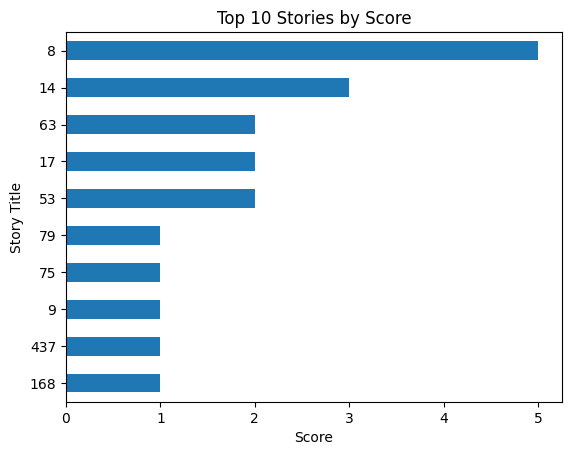

In [7]:
df["score"].value_counts().head(10).plot(kind="barh")
plt.xlabel("Score")
plt.ylabel("Story Title")
plt.title("Top 10 Stories by Score")
plt.gca().invert_yaxis()
plt.savefig("outputs/score_distribution.png")
plt.show()

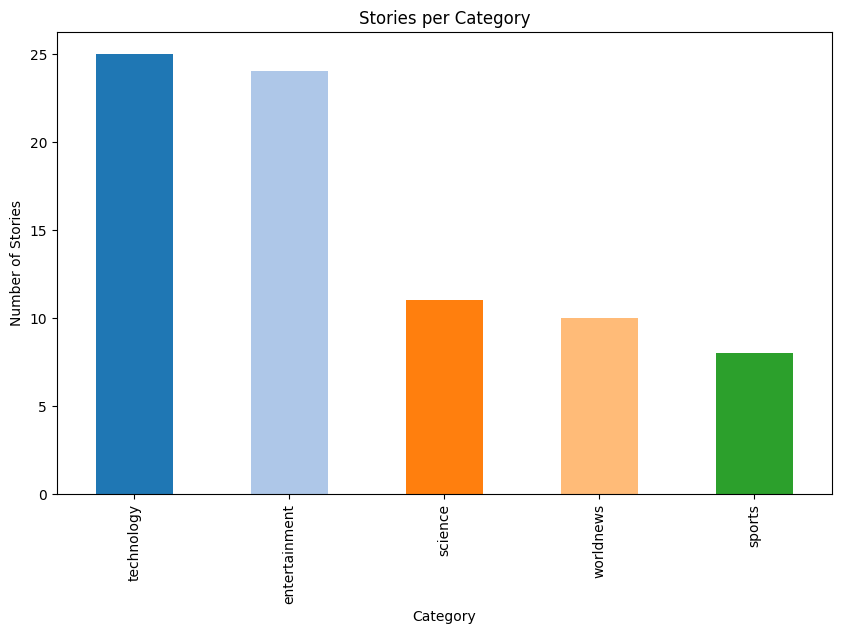

In [8]:
category_counts = df['category'].value_counts()
plt.figure(figsize=(10,6))
category_counts.plot(kind='bar', color=plt.cm.tab20.colors) 
plt.xlabel("Category")
plt.ylabel("Number of Stories")
plt.title("Stories per Category")
plt.savefig("outputs/chart2_category_counts.png", bbox_inches="tight")
plt.show()


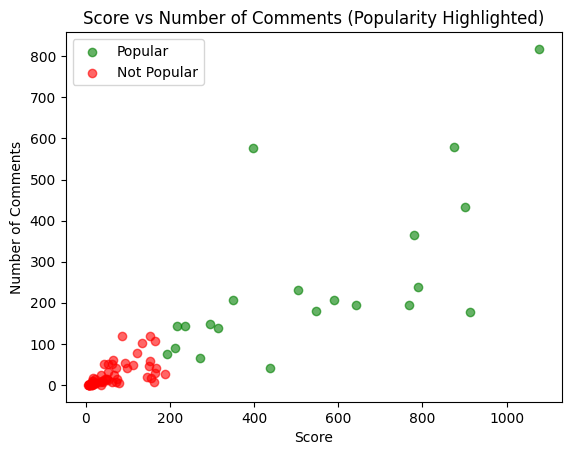

In [9]:
plt.scatter(df[df['is_popular']]['score'],
            df[df['is_popular']]['num_comments'],
            color='green', label='Popular', alpha=0.6)

plt.scatter(df[~df['is_popular']]['score'],
            df[~df['is_popular']]['num_comments'],
            color='red', label='Not Popular', alpha=0.6)
plt.xlabel("Score")
plt.ylabel("Number of Comments")
plt.title("Score vs Number of Comments (Popularity Highlighted)")
plt.legend()
plt.savefig("outputs/chart3_score_vs_comments.png", bbox_inches="tight")
plt.show()

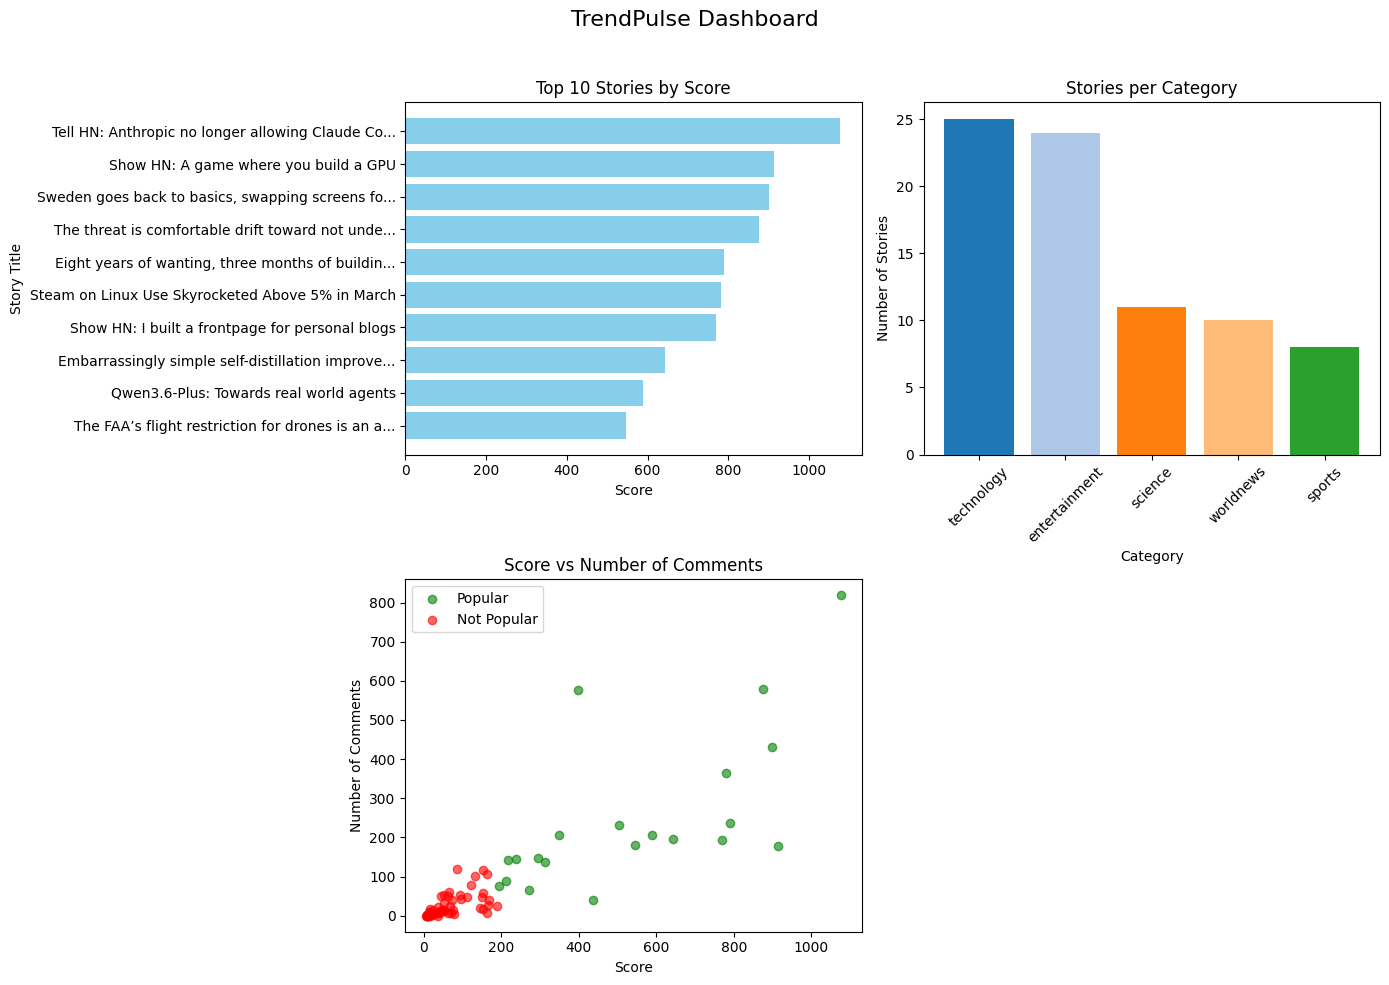

In [10]:

top10 = df.sort_values("score", ascending=False).head(10).copy()
top10["short_title"] = top10["title"].apply(lambda x: x[:47] + "..." if len(x) > 50 else x)


category_counts = df['category'].value_counts()


average_score = df['score'].mean()
df['is_popular'] = df['score'] > average_score


fig, axes = plt.subplots(2, 2, figsize=(14,10))


axes[0,0].barh(top10["short_title"], top10["score"], color="skyblue")
axes[0,0].set_xlabel("Score")
axes[0,0].set_ylabel("Story Title")
axes[0,0].set_title("Top 10 Stories by Score")
axes[0,0].invert_yaxis()

axes[0,1].bar(category_counts.index, category_counts.values, color=plt.cm.tab20.colors)
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Number of Stories")
axes[0,1].set_title("Stories per Category")
axes[0,1].tick_params(axis='x', rotation=45)


axes[1,0].scatter(df[df['is_popular']]['score'],
                  df[df['is_popular']]['num_comments'],
                  color='green', label='Popular', alpha=0.6)
axes[1,0].scatter(df[~df['is_popular']]['score'],
                  df[~df['is_popular']]['num_comments'],
                  color='red', label='Not Popular', alpha=0.6)
axes[1,0].set_xlabel("Score")
axes[1,0].set_ylabel("Number of Comments")
axes[1,0].set_title("Score vs Number of Comments")
axes[1,0].legend()


axes[1,1].axis("off")


fig.suptitle("TrendPulse Dashboard", fontsize=16)


plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("outputs/trendpulse_dashboard.png", bbox_inches="tight")
plt.show()
